In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/bhanupratapbiswas/website-traffic-analysis/traffic.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/kaggle/input/datasets/bhanupratapbiswas/website-traffic-analysis/traffic.csv')

df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [4]:
df.shape

(226278, 9)

In [5]:
df.columns

Index(['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc',
       'linkid'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    226278 non-null  object
 1   date     226278 non-null  object
 2   country  226267 non-null  object
 3   city     226267 non-null  object
 4   artist   226241 non-null  object
 5   album    226273 non-null  object
 6   track    226273 non-null  object
 7   isrc     219157 non-null  object
 8   linkid   226278 non-null  object
dtypes: object(9)
memory usage: 15.5+ MB


In [7]:
df.describe()

,event,date,country,city,artist,album,track,isrc,linkid
count,226278,226278,226267,226267,226241,226273,226273,219157,226278
unique,3,7,211,11993,2419,3254,3562,709,3839
top,pageview,2021-08-19,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
freq,142015,35361,47334,22791,40841,40841,40841,40841,40841


In [8]:
df.isnull().sum()

event         0
date          0
country      11
city         11
artist       37
album         5
track         5
isrc       7121
linkid        0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(103711)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].mean())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna('Unknown')

In [13]:
df.isnull().sum()

event      0
date       0
country    0
city       0
artist     0
album      0
track      0
isrc       0
linkid     0
dtype: int64

In [14]:
df.dtypes

event      object
date       object
country    object
city       object
artist     object
album      object
track      object
isrc       object
linkid     object
dtype: object

In [15]:
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Plot only if numeric columns exist
if not numeric_df.empty:
    numeric_df.hist(figsize=(12,8))
    plt.show()
else:
    print("No numeric columns available for histogram.")

No numeric columns available for histogram.


In [16]:
df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
5,click,2021-08-21,United States,Los Angeles,KenTheMan,I'm Perfect,I'm Perfect,US39N2102090,190c7170-4044-4c97-9709-926917155b02


In [17]:
df.columns

Index(['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc',
       'linkid'],
      dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 122567 entries, 0 to 226274
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    122567 non-null  object
 1   date     122567 non-null  object
 2   country  122567 non-null  object
 3   city     122567 non-null  object
 4   artist   122567 non-null  object
 5   album    122567 non-null  object
 6   track    122567 non-null  object
 7   isrc     122567 non-null  object
 8   linkid   122567 non-null  object
dtypes: object(9)
memory usage: 9.4+ MB


In [19]:
df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
5,click,2021-08-21,United States,Los Angeles,KenTheMan,I'm Perfect,I'm Perfect,US39N2102090,190c7170-4044-4c97-9709-926917155b02


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 122567 entries, 0 to 226274
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    122567 non-null  object
 1   date     122567 non-null  object
 2   country  122567 non-null  object
 3   city     122567 non-null  object
 4   artist   122567 non-null  object
 5   album    122567 non-null  object
 6   track    122567 non-null  object
 7   isrc     122567 non-null  object
 8   linkid   122567 non-null  object
dtypes: object(9)
memory usage: 9.4+ MB


In [21]:
df.isnull().sum()

event      0
date       0
country    0
city       0
artist     0
album      0
track      0
isrc       0
linkid     0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.drop_duplicates(inplace=True)

In [24]:
df.fillna('Unknown', inplace=True)

In [25]:
df['date'] = pd.to_datetime(df['date'])

In [26]:
df['event'].value_counts()

event
pageview    73360
click       32499
preview     16708
Name: count, dtype: int64

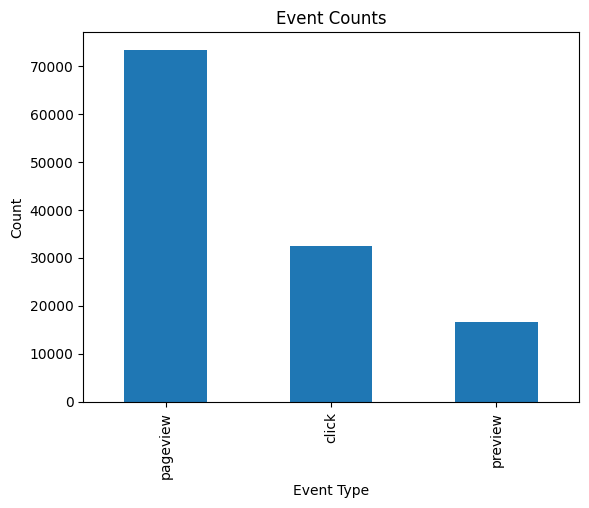

In [27]:
import matplotlib.pyplot as plt

df['event'].value_counts().plot(kind='bar')

plt.title('Event Counts')
plt.xlabel('Event Type')
plt.ylabel('Count')

plt.show()

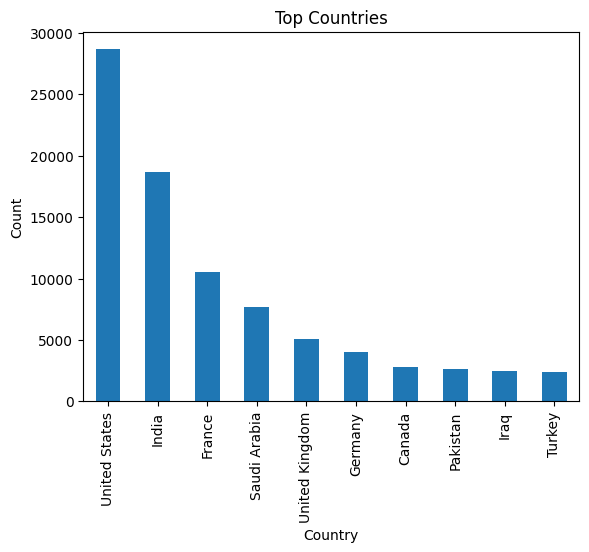

In [28]:
df['country'].value_counts().head(10).plot(kind='bar')

plt.title('Top Countries')
plt.xlabel('Country')
plt.ylabel('Count')

plt.show()

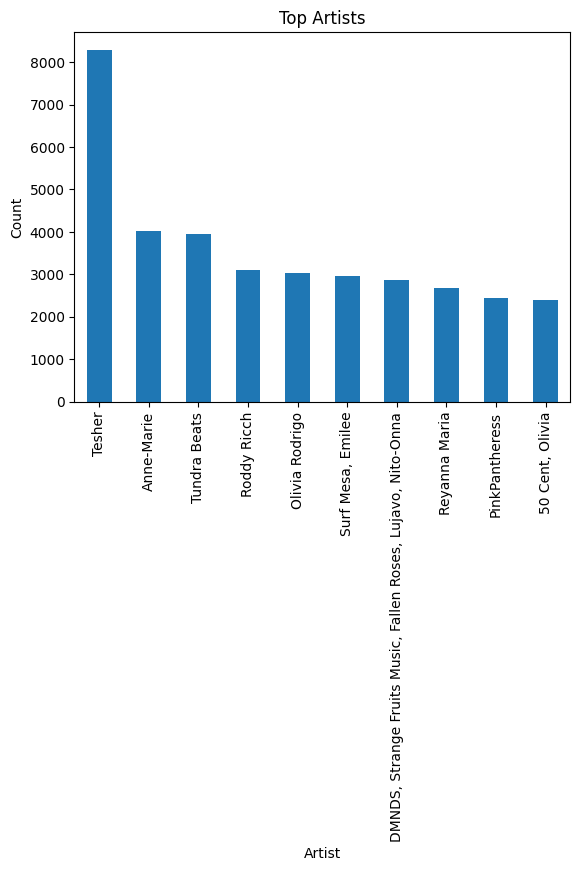

In [29]:
df['artist'].value_counts().head(10).plot(kind='bar')

plt.title('Top Artists')
plt.xlabel('Artist')
plt.ylabel('Count')

plt.show()

In [33]:
df.to_csv('cleaned_traffic.csv', index=False)

In [34]:
df.to_csv('cleaned_traffic.csv', index=False)

   event        date       country      city  \
0  click  2021-08-21  Saudi Arabia    Jeddah   
1  click  2021-08-21  Saudi Arabia    Jeddah   
2  click  2021-08-21         India  Ludhiana   
3  click  2021-08-21        France   Unknown   
4  click  2021-08-21      Maldives      Malé   

                              artist          album          track  \
0                             Tesher    Jalebi Baby    Jalebi Baby   
1                             Tesher    Jalebi Baby    Jalebi Baby   
2                      Reyanna Maria      So Pretty      So Pretty   
3  Simone & Simaria, Sebastian Yatra  No Llores Más  No Llores Más   
4                             Tesher    Jalebi Baby    Jalebi Baby   

           isrc                                linkid  
0  QZNWQ2070741  2d896d31-97b6-4869-967b-1c5fb9cd4bb8  
1  QZNWQ2070741  2d896d31-97b6-4869-967b-1c5fb9cd4bb8  
2  USUM72100871  23199824-9cf5-4b98-942a-34965c3b0cc2  
3  BRUM72003904  35573248-4e49-47c7-af80-08a960fa74cd  
4  QZNWQ20

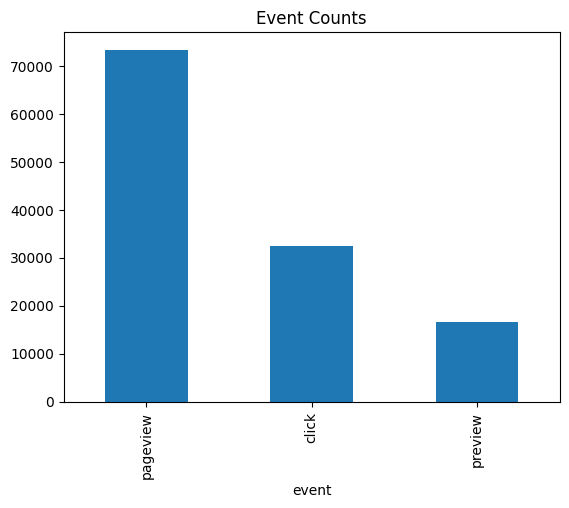

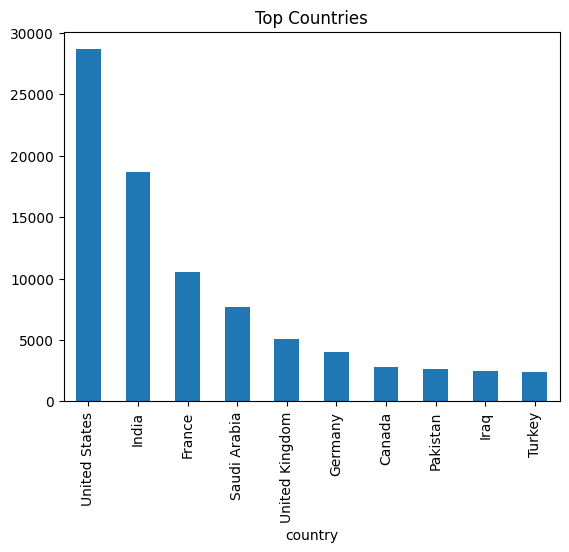

Project Completed Successfully


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/kaggle/input/datasets/bhanupratapbiswas/website-traffic-analysis/traffic.csv')

# View dataset
print(df.head())

# Dataset info
print(df.info())

# Missing values
print(df.isnull().sum())

# Duplicate rows
print(df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fill missing values
df.fillna('Unknown', inplace=True)

# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Event count visualization
df['event'].value_counts().plot(kind='bar')
plt.title('Event Counts')
plt.show()

# Top countries
df['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top Countries')
plt.show()

# Save cleaned dataset
df.to_csv('cleaned_traffic.csv', index=False)

print("Project Completed Successfully")

# Conclusion

The dataset was successfully cleaned and analyzed.
Missing values and duplicates were handled properly.
Basic visualizations were created to understand user events, countries, and artists.
The cleaned dataset was exported successfully.